# RFS Classification

## 모듈 로딩

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import glob
import cv2
from sklearn.model_selection import train_test_split

print("NumPy Version :{}".format(np.__version__))
print("TensorFlow Version :{}".format(tf.__version__))
print("Matplotlib Version :{}".format(plt.matplotlib.__version__))

NumPy Version :2.0.2
TensorFlow Version :2.19.0
Matplotlib Version :3.10.0


## g-drive 마운트

In [ ]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    print('g-drive mounted.')
    colab=True
except:
    print('local drive.')
    colab =False

Mounted at /content/drive
g-drive mounted.


## RPS 데이터셋 준비

In [ ]:
# files_path: 다른 경로에 실습파일을 복사했다면, 아래 경로를 수정하세요

if colab :
  !unzip -q -o /content/drive/MyDrive/files/RPS_Dataset.zip
  files_path = '/content/RPS_Dataset'
else :
  files_path = '../files/RPS_Dataset'

## 폴더 별로 파일 읽어 데이터화 진행

In [ ]:
%%time
first = True
IMG_SIZE = 64
for ind in range(0, 3, 1) :
    path = files_path + '/' + str(ind) + '/*.*'
    print(path)
    files = glob.glob(path)
    tmpx = np.array([(cv2.resize(cv2.cvtColor(cv2.imread(x, cv2.IMREAD_COLOR), cv2.COLOR_BGR2RGB), (IMG_SIZE,IMG_SIZE))) for x in files])
    tmpy = np.array([ind] * len(files))

    xtrain, xtest, ytrain, ytest = train_test_split(tmpx, tmpy, test_size=0.2, random_state=123)

    if first == True:
        train_data = xtrain.copy()
        train_labels = ytrain.copy()
        test_data = xtest.copy()
        test_labels = ytest.copy()
        first = False
    else :
        train_data = np.concatenate((train_data, xtrain))
        train_labels = np.concatenate((train_labels, ytrain))
        test_data = np.concatenate((test_data, xtest))
        test_labels = np.concatenate((test_labels, ytest))

/content/RPS_Dataset/0/*.*
/content/RPS_Dataset/1/*.*
/content/RPS_Dataset/2/*.*
CPU times: user 7.64 s, sys: 252 ms, total: 7.89 s
Wall time: 8.05 s


## 데이터 확인

In [ ]:
# 0~1로 변환 처리 안함 (모델 내에서 처리함)
# train_data = train_data / 255.0
# test_data = test_data / 255.0

print(train_data.shape)
print(train_labels.shape)
print(test_data.shape)
print(test_labels.shape)

(2172, 64, 64, 3)
(2172,)
(545, 64, 64, 3)
(545,)


## 모델 생성


In [ ]:
denseNet = tf.keras.applications.densenet.DenseNet121(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = tf.keras.applications.densenet.preprocess_input(inputs)
x = denseNet(x, training = False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.2)(x)
outputs = tf.keras.layers.Dense(3, activation='softmax')(x)

model = tf.keras.Model(inputs, outputs)

model.summary()

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ add (Add)                       │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_1 (TrueDivide)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 2, 2, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │         3,075 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,040,579 (26.86 MB)

 Trainable params: 6,956,931 (26.54 MB)

 Non-trainable params: 83,648 (326.75 KB)

## 모델 컴파일

In [ ]:
model.compile(optimizer= tf.keras.optimizers.Adam(learning_rate=0.0005),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

## 학습 전 상황

In [ ]:
def Make_Result_Plot(suptitle, data, label, y_max):
    size = data.shape[0]//10
    fig_result, ax_result = plt.subplots(2,5,figsize=(18, 7))
    fig_result.suptitle(suptitle)
    for idx in range(10):
        cnt = idx * size + size//2
        ax_result[idx//5,idx%5].imshow(data[cnt].reshape((IMG_SIZE,IMG_SIZE, 3)))
        ax_result[idx//5,idx%5].set_title("test_data[{}] (label : {} / y : {})".format(cnt, label[cnt], y_max[cnt]))

18/18 ━━━━━━━━━━━━━━━━━━━━ 28s 736ms/step


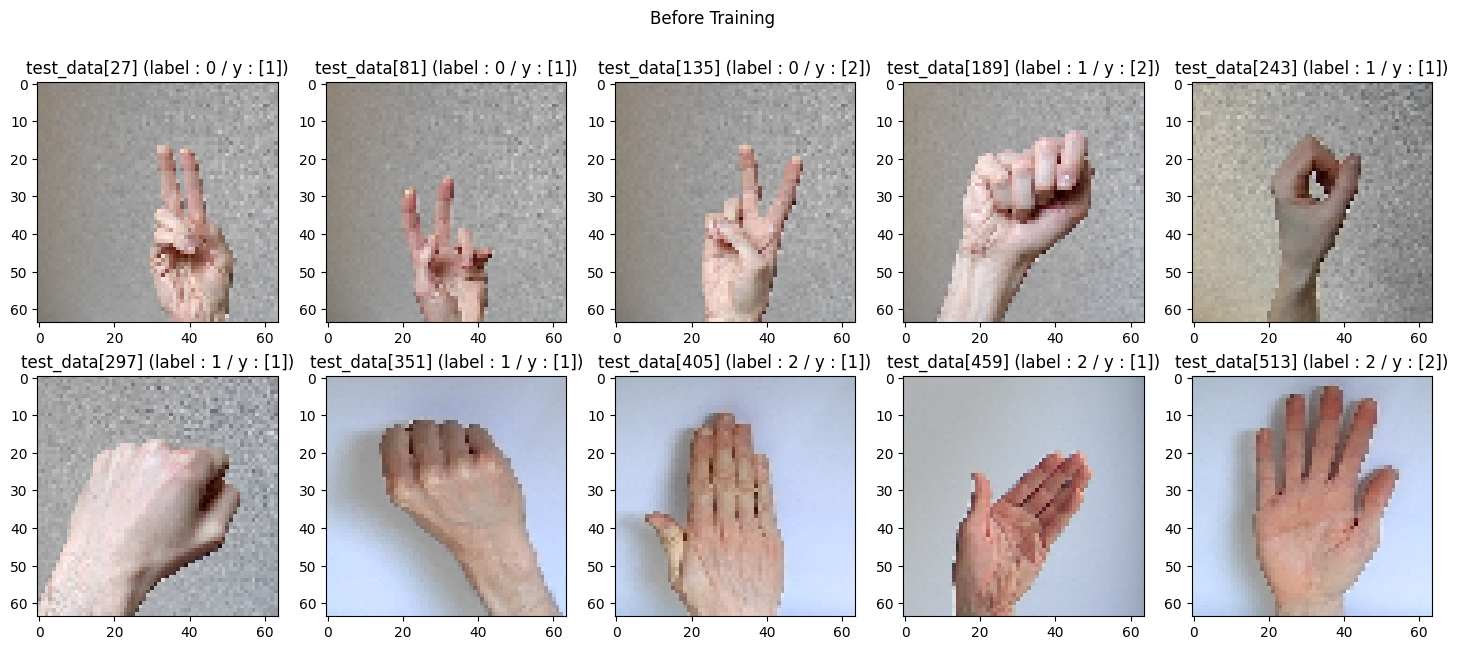

In [ ]:
y_out = model.predict(test_data)
y_max = np.argmax(y_out, axis=1).reshape((-1, 1))
Make_Result_Plot("Before Training", test_data, test_labels, y_max)

## 콜백 설정

In [ ]:
savedModelName = 'RPS_PreTrained_DenseNet.keras'
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(savedModelName,
                                    save_best_only=True)
]

## 모델 학습

In [ ]:
%%time
history = model.fit(train_data, train_labels, epochs=30,
                    callbacks=callbacks,
                    validation_data=(test_data, test_labels))

Epoch 1/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 282s 2s/step - accuracy: 0.8155 - loss: 0.5248 - val_accuracy: 0.9615 - val_loss: 0.3839
Epoch 2/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 6s 80ms/step - accuracy: 0.9889 - loss: 0.0411 - val_accuracy: 0.9908 - val_loss: 0.0401
Epoch 3/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 6s 84ms/step - accuracy: 0.9942 - loss: 0.0219 - val_accuracy: 0.9835 - val_loss: 0.0301
Epoch 4/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 10s 80ms/step - accuracy: 0.9980 - loss: 0.0067 - val_accuracy: 0.9908 - val_loss: 0.0176
Epoch 5/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 4s 63ms/step - accuracy: 0.9886 - loss: 0.0814 - val_accuracy: 0.9890 - val_loss: 0.0314
Epoch 6/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - accuracy: 0.9952 - loss: 0.0145 - val_accuracy: 0.9541 - val_loss: 0.2846
Epoch 7/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - accuracy: 0.9898 - loss: 0.0501 - val_accuracy: 0.9798 - val_loss: 0.1187
Epoch 8/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 4s 61ms/step - accuracy: 0.9980 - loss: 0.0111 - val_accuracy: 0.9945 - 

## Ploting : Cost/Training Count

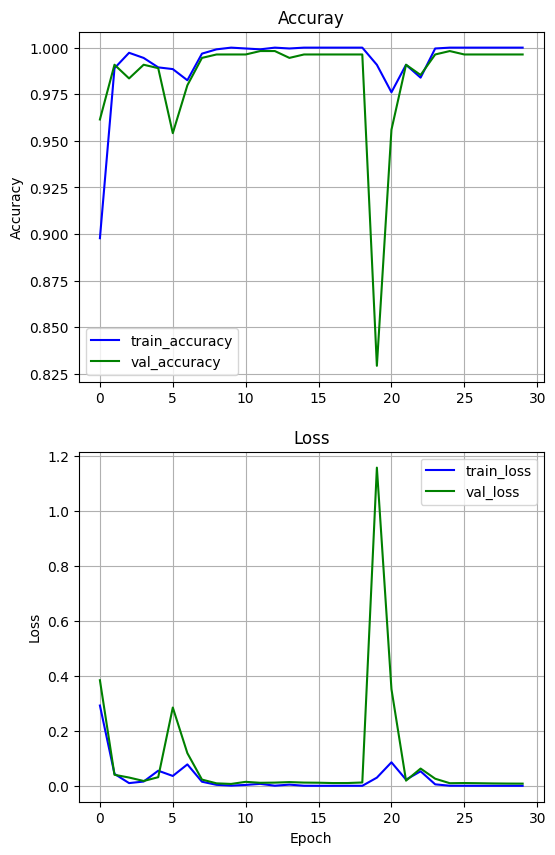

In [ ]:
plt.figure(figsize=(6, 10))
plt.subplot(2, 1, 1)
plt.title('Accuray')
plt.plot(history.history['accuracy'], 'b', label='train_accuracy')
plt.plot(history.history['val_accuracy'], 'g', label='val_accuracy')
plt.grid(True)
plt.ylabel('Accuracy')
plt.legend(loc='best')

plt.subplot(2, 1, 2)
plt.title('Loss')
plt.plot(history.history['loss'], 'b', label='train_loss')
plt.plot(history.history['val_loss'], 'g', label='val_loss')
plt.grid(True)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='best')
plt.show()

## best 모델 로딩 및 테스트

In [ ]:
model_best = tf.keras.models.load_model(savedModelName)

18/18 ━━━━━━━━━━━━━━━━━━━━ 24s 651ms/step


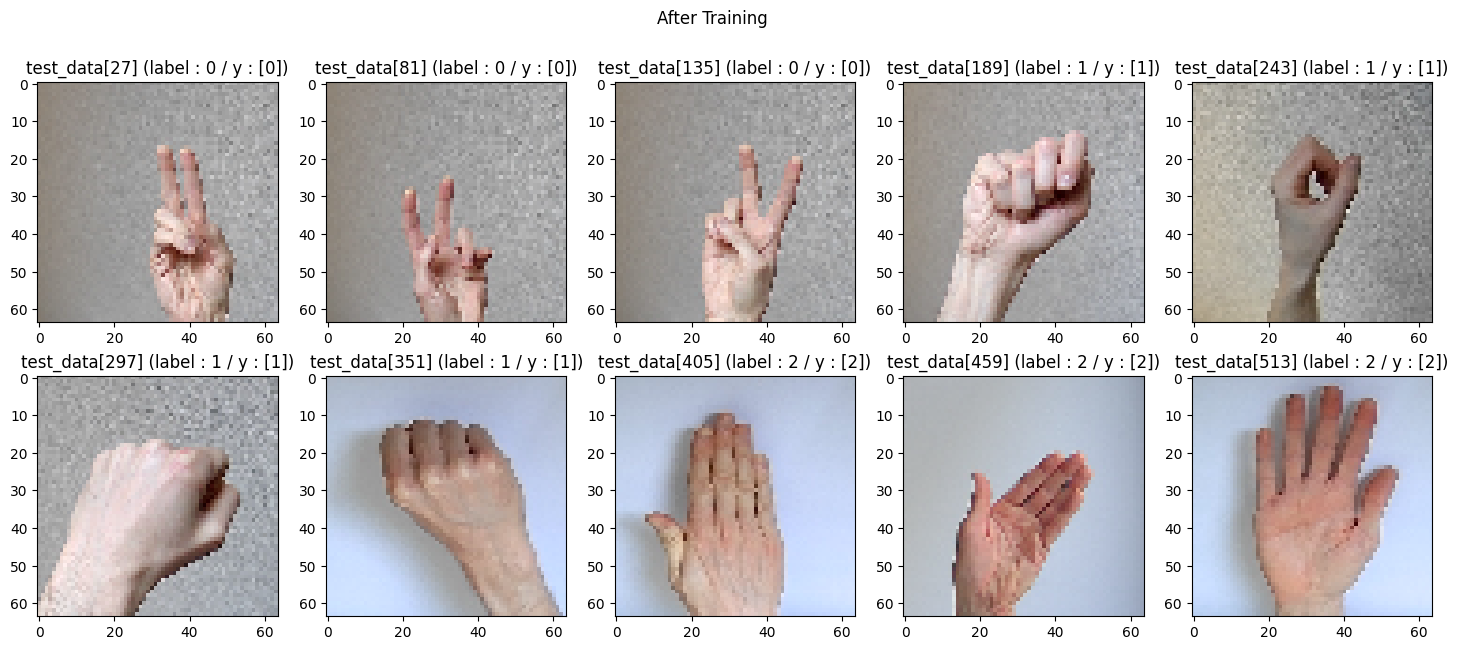

In [ ]:
y_out = model_best.predict(test_data)
y_max = np.argmax(y_out, axis=1).reshape((-1, 1))
Make_Result_Plot("After Training", test_data, test_labels, y_max)

## best 모델 백업

In [ ]:
# save_dir: 다른 경로에 저장하려면, 아래 경로를 수정하세요
if colab :
  save_dir = '/content/drive/MyDrive/files/save/'
else :
  save_dir = '../files/save/'

In [ ]:
# copy saved mode
cpCmd = f'cp {savedModelName} {save_dir}'
print(cpCmd)
!{cpCmd}

cp RPS_PreTrained_DenseNet.keras /content/drive/MyDrive/files/save/


## LiteRT 모델로 변환

In [ ]:
converter = tf.lite.TFLiteConverter.from_keras_model(model_best)
tflite_model = converter.convert()

Saved artifact at '/tmp/tmp5mj3rek0'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 64, 64, 3), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  132139966638672: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  132139966638864: TensorSpec(shape=(3,), dtype=tf.float32, name=None)
  132142389078224: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132142389076304: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132142389075536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132142389076112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132142389074960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132142389069968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132142389072656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132142389074576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13214

## LiteRT 모델을 파일로 저장

In [ ]:
tfliteFileName = 'RPS_PreTrained_DenseNet.tflite'

In [ ]:
open(save_dir + tfliteFileName, 'wb').write(tflite_model)

27915552